In [1]:
import calpgs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = "DejaVu Sans"
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['font.size'] = 16

# LDL

Overall
Age
Sex
Income
Education


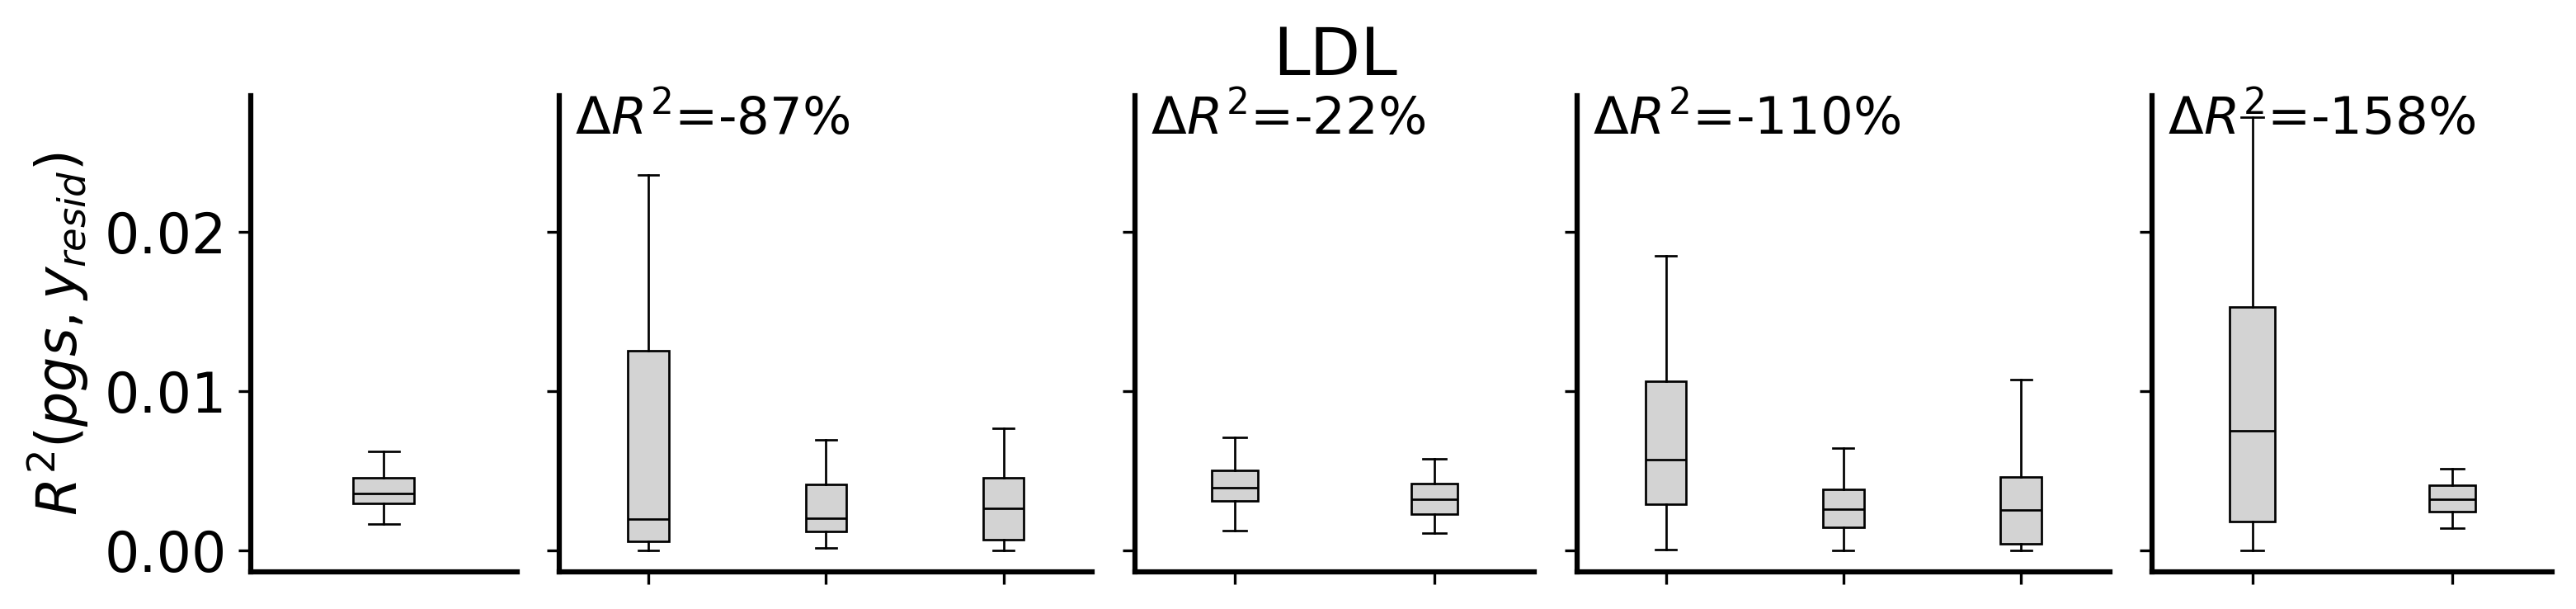

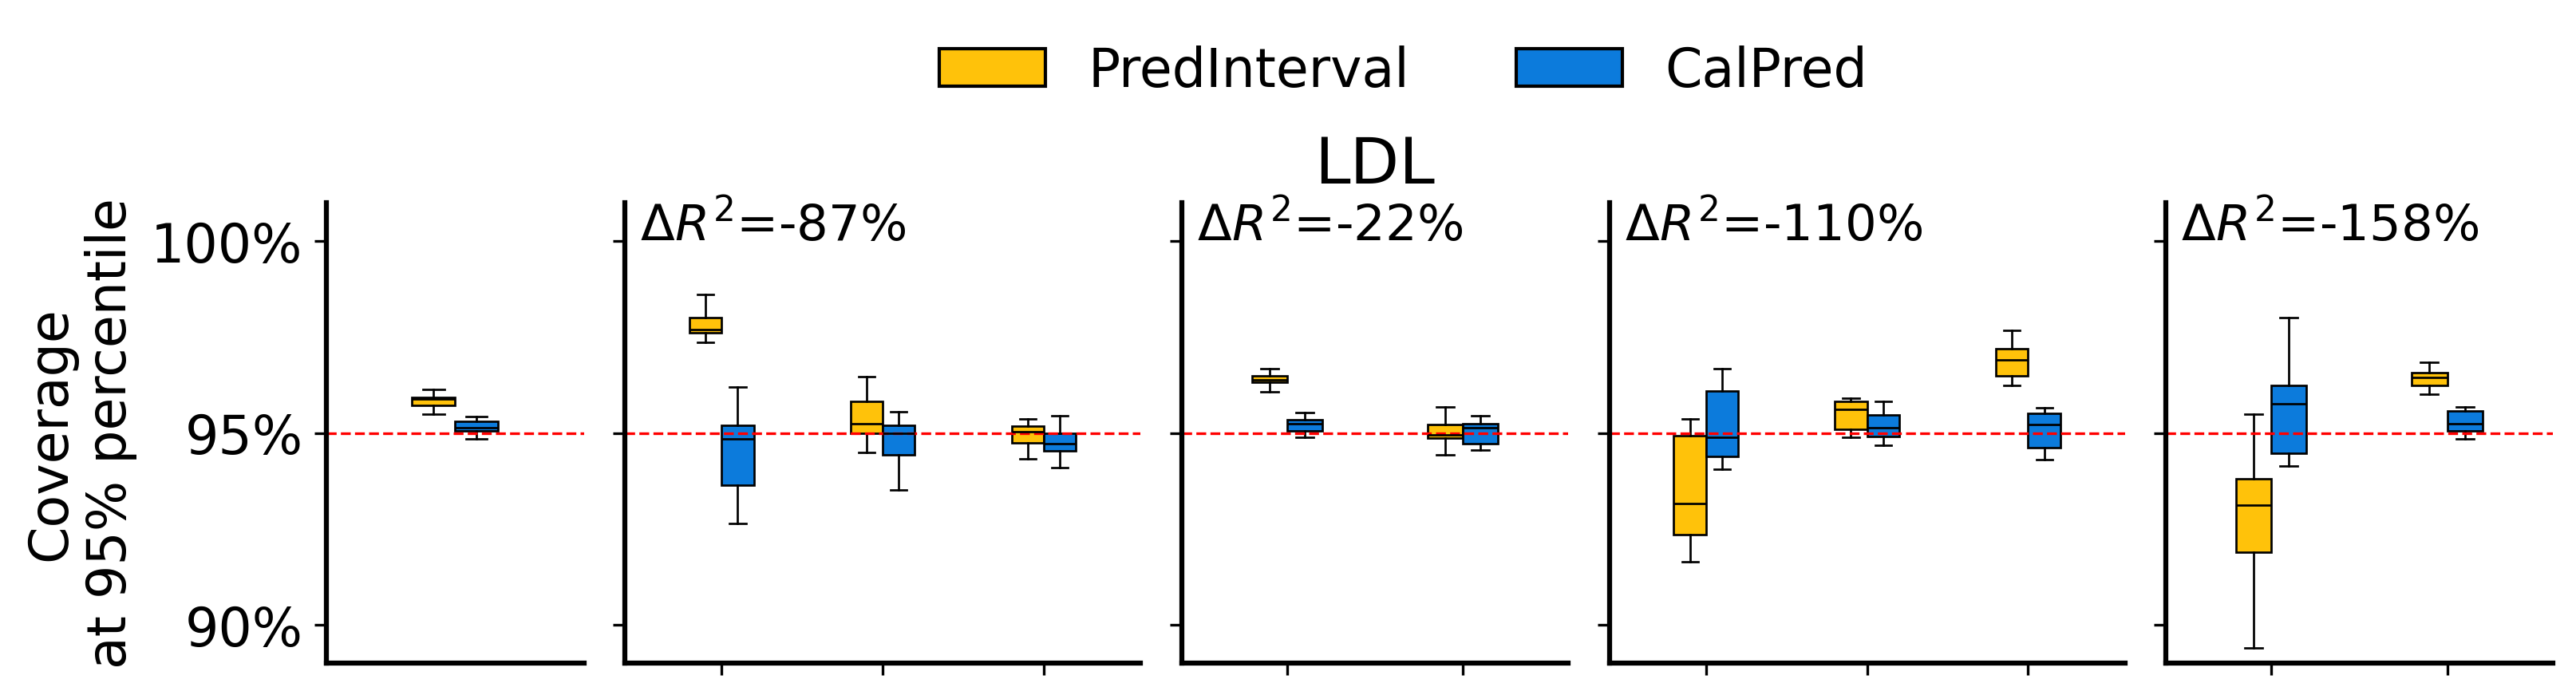

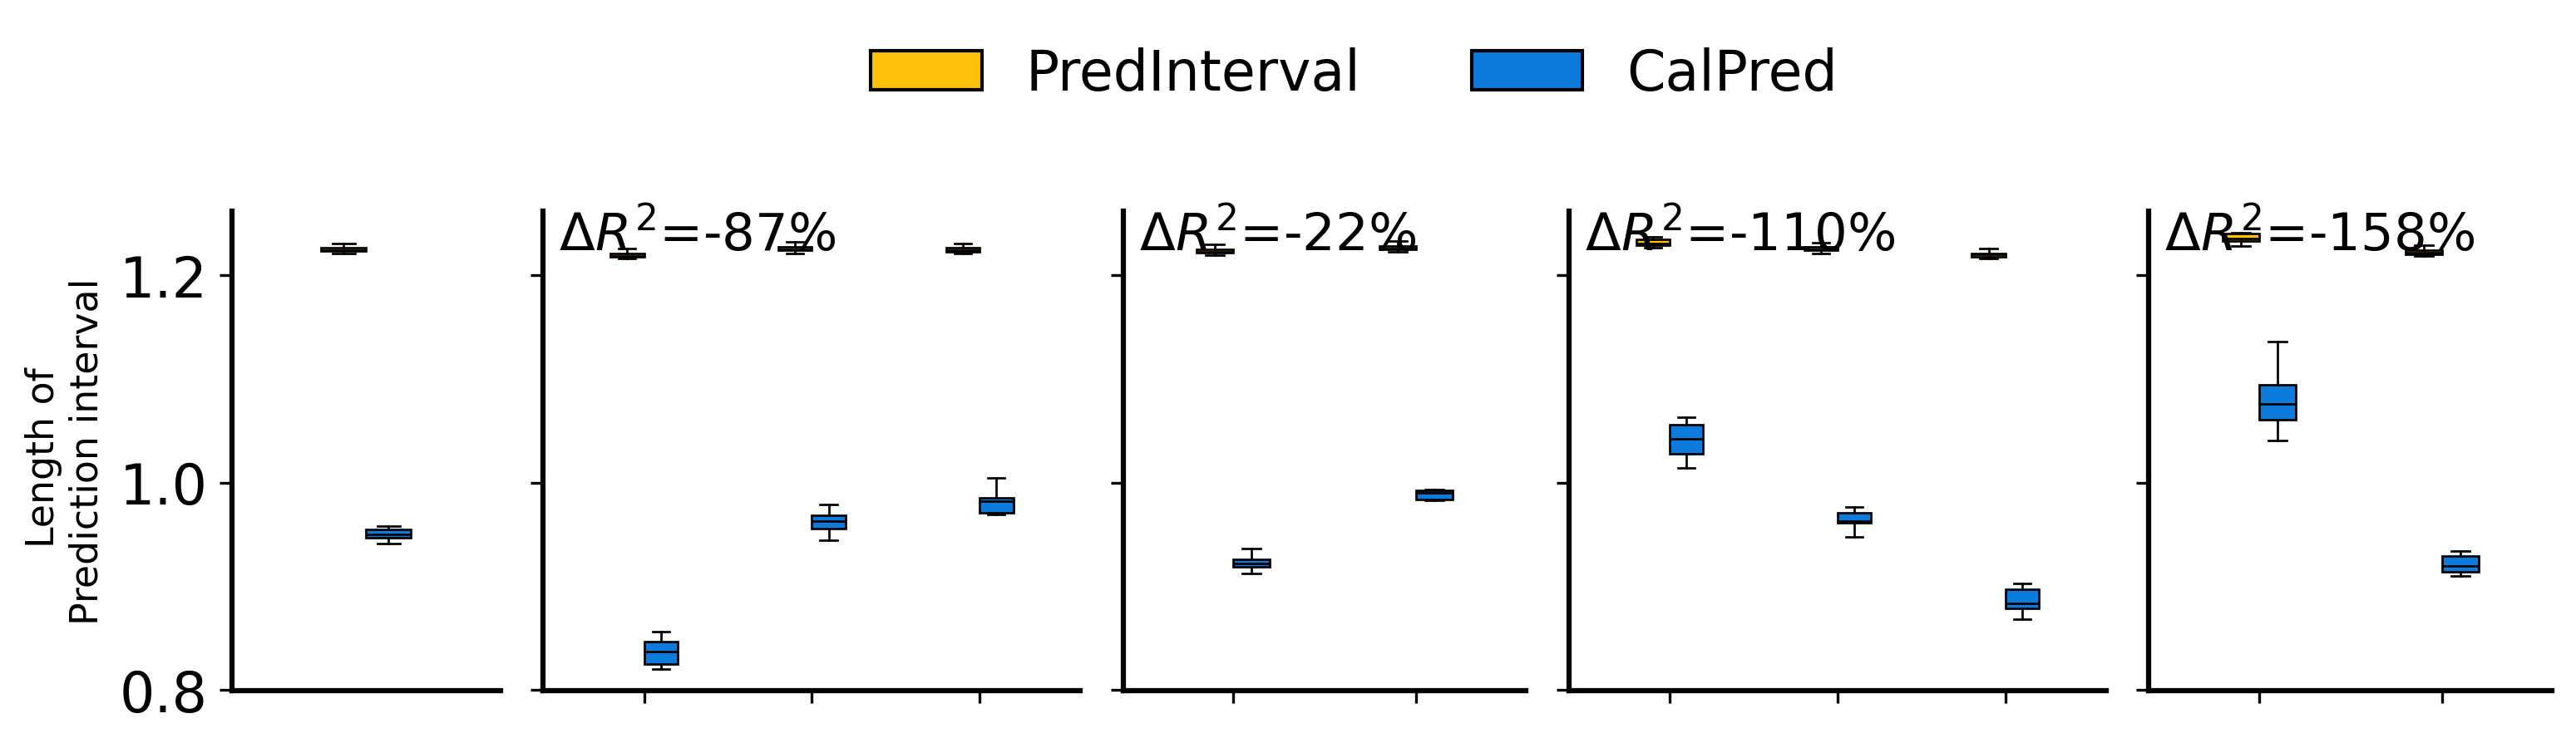

In [2]:
def fix_xaxis(axes,none=False,r2=None):
    axes[0].set_xticks([])
    if none:
        for i in range(0,5):
            axes[i].set_xticklabels([])
            axes[i].set_xlabel("")
    else:

        axes[1].set_xlabel("Age Strata")
        axes[1].set_xticklabels(["Top","Middle","Bottom"],fontsize=12)

        axes[2].set_xlabel("Sex")
        axes[2].set_xticklabels(["Female", "Male"],fontsize=15)
        axes[3].set_xlabel("Income Strata")
        axes[3].set_xticklabels(["Top","Middle","Bottom"],fontsize=12)
        axes[4].set_xlabel("Education Strata")
        axes[4].set_xticklabels(["Top","Bottom"],fontsize=15)
        
    for ax in axes:
        ax.spines[['right', 'top']].set_visible(False)
    contexts = [("age",0,9),("sex",0,1),("income",1,9),("education",1,4)]
    
    deltas=[]
    
    contexts = [("age",0,9),("sex",0,1),("income",1,9),("education",1,4)]
    for context in contexts:
        values = []
        for seed in range(10):
            for cv in range(1,6):
                values.append((r2[(r2.col==f"{context[0]}_q_{context[2]}") & (r2.seed == seed) & (r2.cv==cv)].r2.values[0]-r2[(r2.col==f"{context[0]}_q_{context[1]}") & (r2.seed == seed) & (r2.cv==cv)].r2.values[0])/r2[(r2.col==f"marginal") & (r2.seed == seed) & (r2.cv==cv)].r2.values[0])
        deltas.append(np.mean(values))


    for i in range(4):
        deltar2 = deltas[i]
        axes[i+1].set_title(f" $\\Delta R^2$={deltar2:.0%}",fontsize=15,loc="left",y=0.875)


r2 = pd.read_csv("data/f3_LDL_r2.tsv",sep="\t").fillna("")
df_tmp = pd.read_csv("data/f3_LDL_result.tsv",sep="\t").fillna("")   

# plot
fig_r2, axes_r2 = calpgs.plot_group_r2(
    df=r2,
    groups=["Overall", "Age","Sex","Income", "Education"],
    figsize=(12, 2.5)
)
axes_r2[2].set_title("LDL")
axes_r2[0].set_ylabel("$R^2 (pgs, y_{resid})$", fontsize=16)


fig_coverage, axes_coverage, fig_length, axes_length = calpgs.plot_group_predint(
    df=df_tmp,
    pos_offset=0.2,
    figsize=(12,2.5),
    groups=["Overall", "Age","Sex","Income", "Education"],
    methods=["PredInterval","CalPred"],
    method_colors={"CalPred": "#0C7BDC", "PredInterval":"#FFC20A"},
    legend_bbox_to_anchor=(0.5, 1.1),
    legend_fontsize=16
)
axes_coverage[2].set_title("LDL")
axes_coverage[0].set_ylabel("Coverage\nat 95% percentile", fontsize=16)
for ax in axes_coverage:
    ax.set_ylim(0.89, 1.01)
    ax.axhline(y=0.95, color="red", lw=0.8, ls="--")

    
for axes in [axes_r2, axes_coverage, axes_length]:
    fix_xaxis(axes,True,r2)


fig_coverage.savefig("figures/fig3_ldl_gwas_alpha95.PGS_resid.png",bbox_inches='tight')
fig_r2.savefig("figures/fig3_ldl_gwas_alpha95.r2.PGS_resid.png",bbox_inches='tight')


# BMI

Overall
Age
Sex
Income
Education


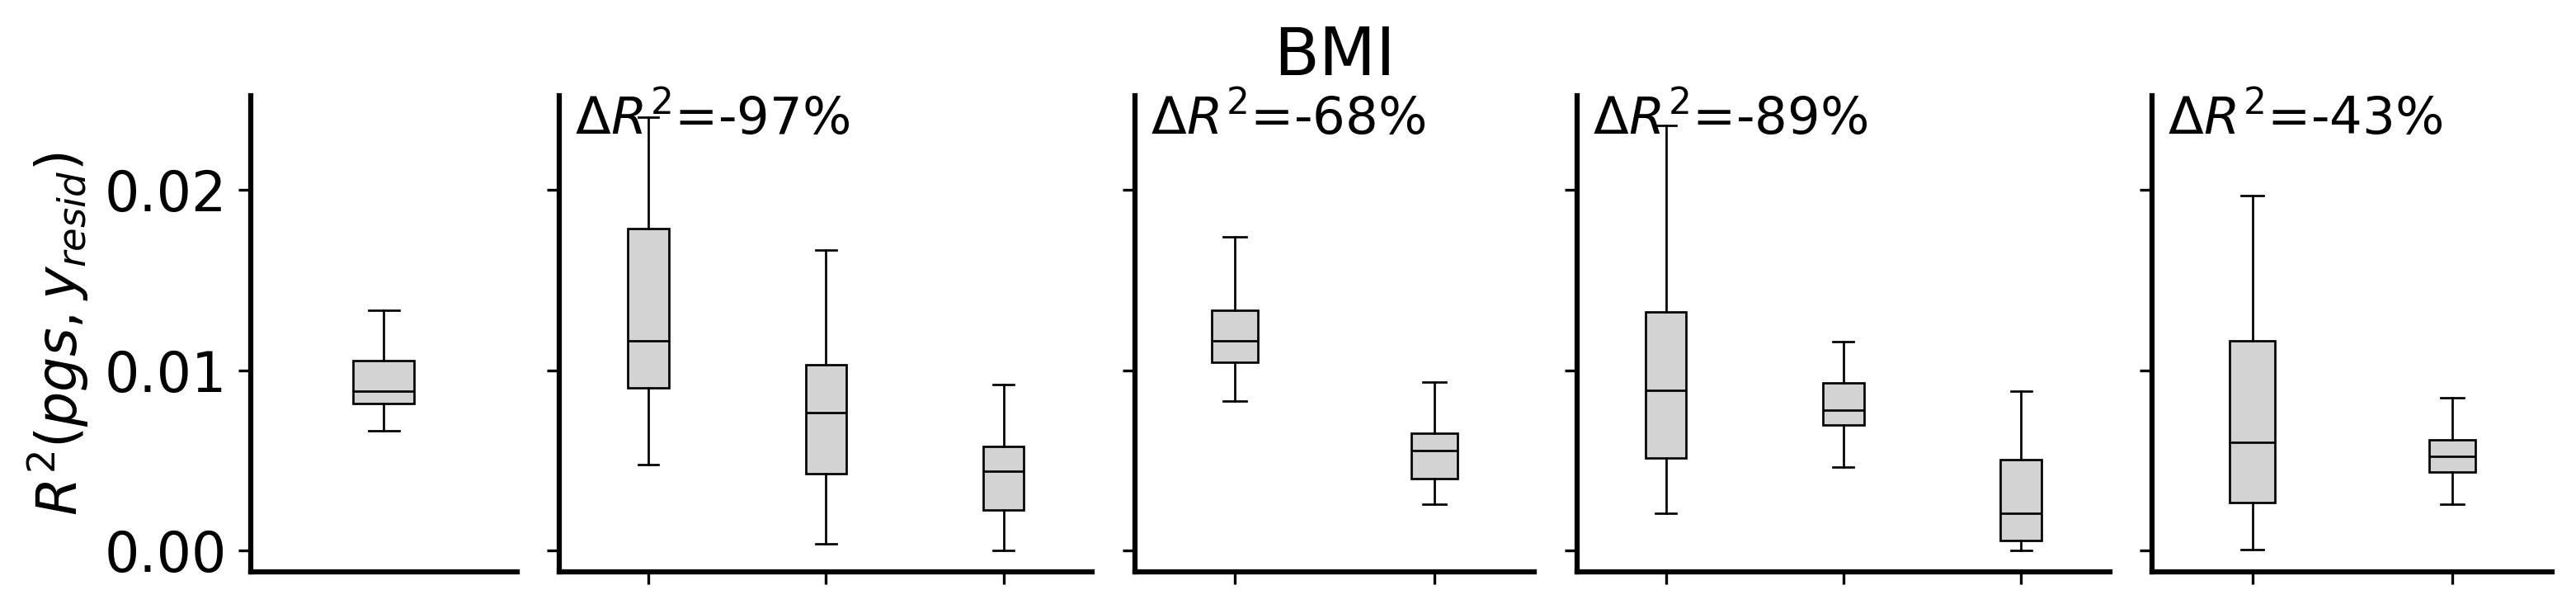

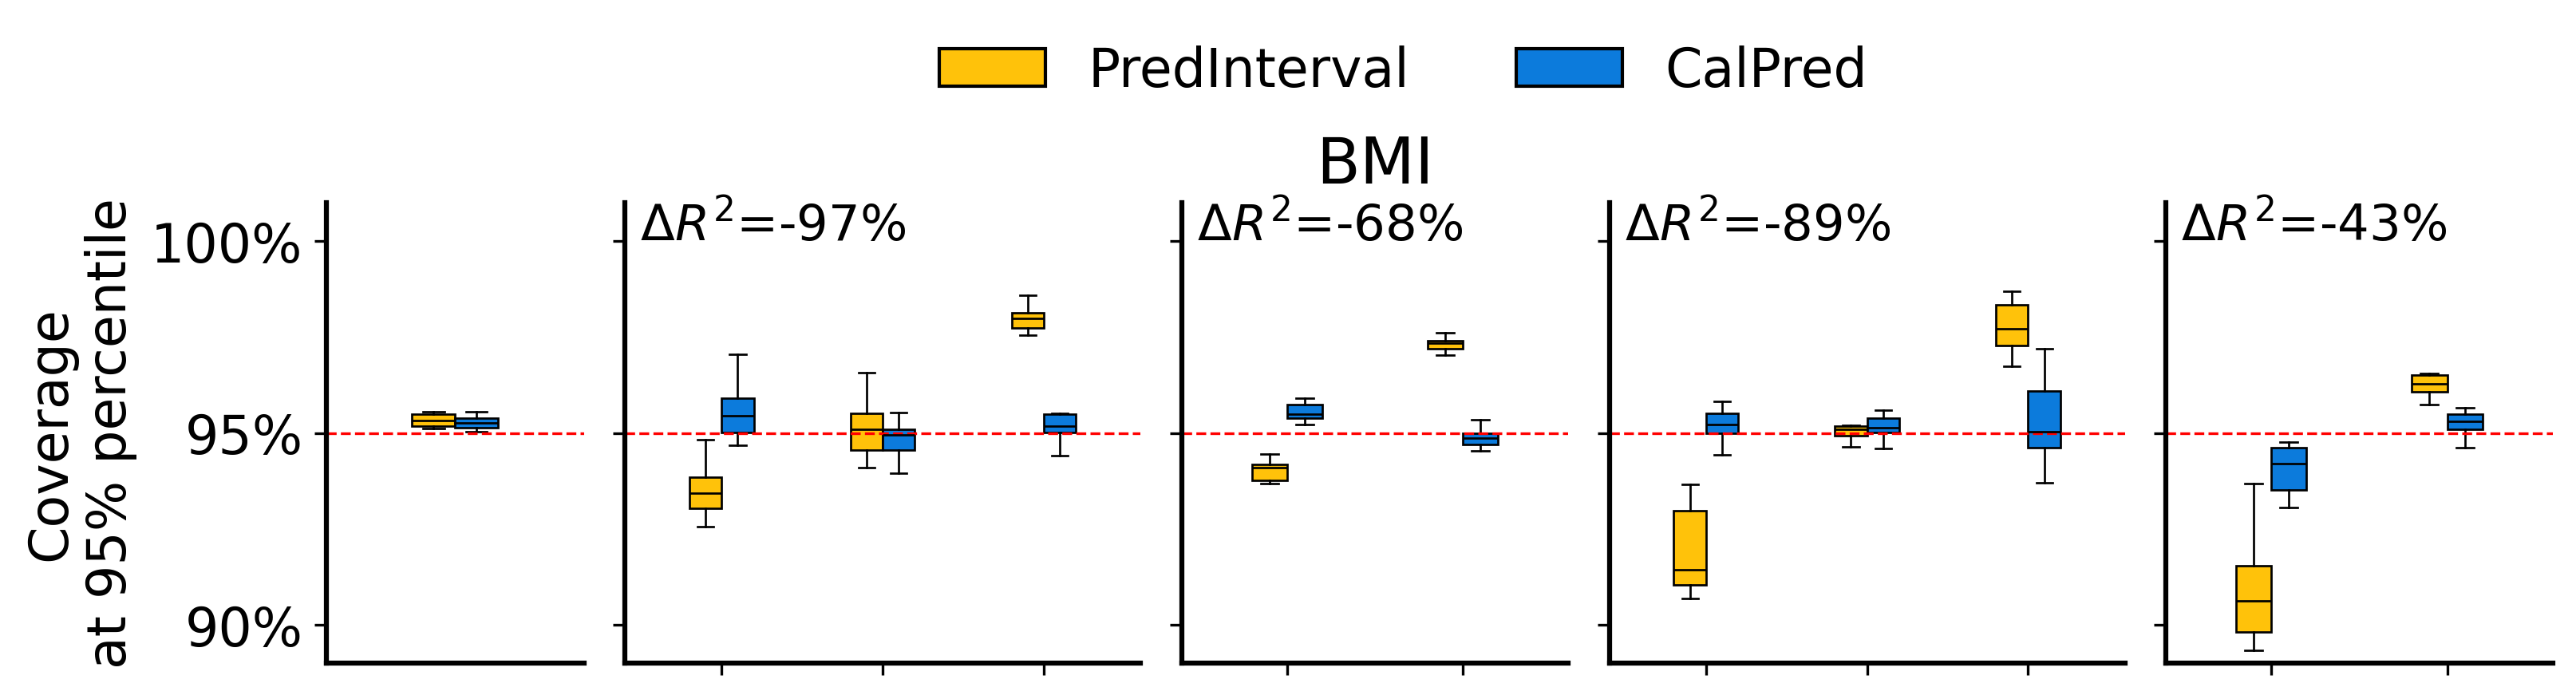

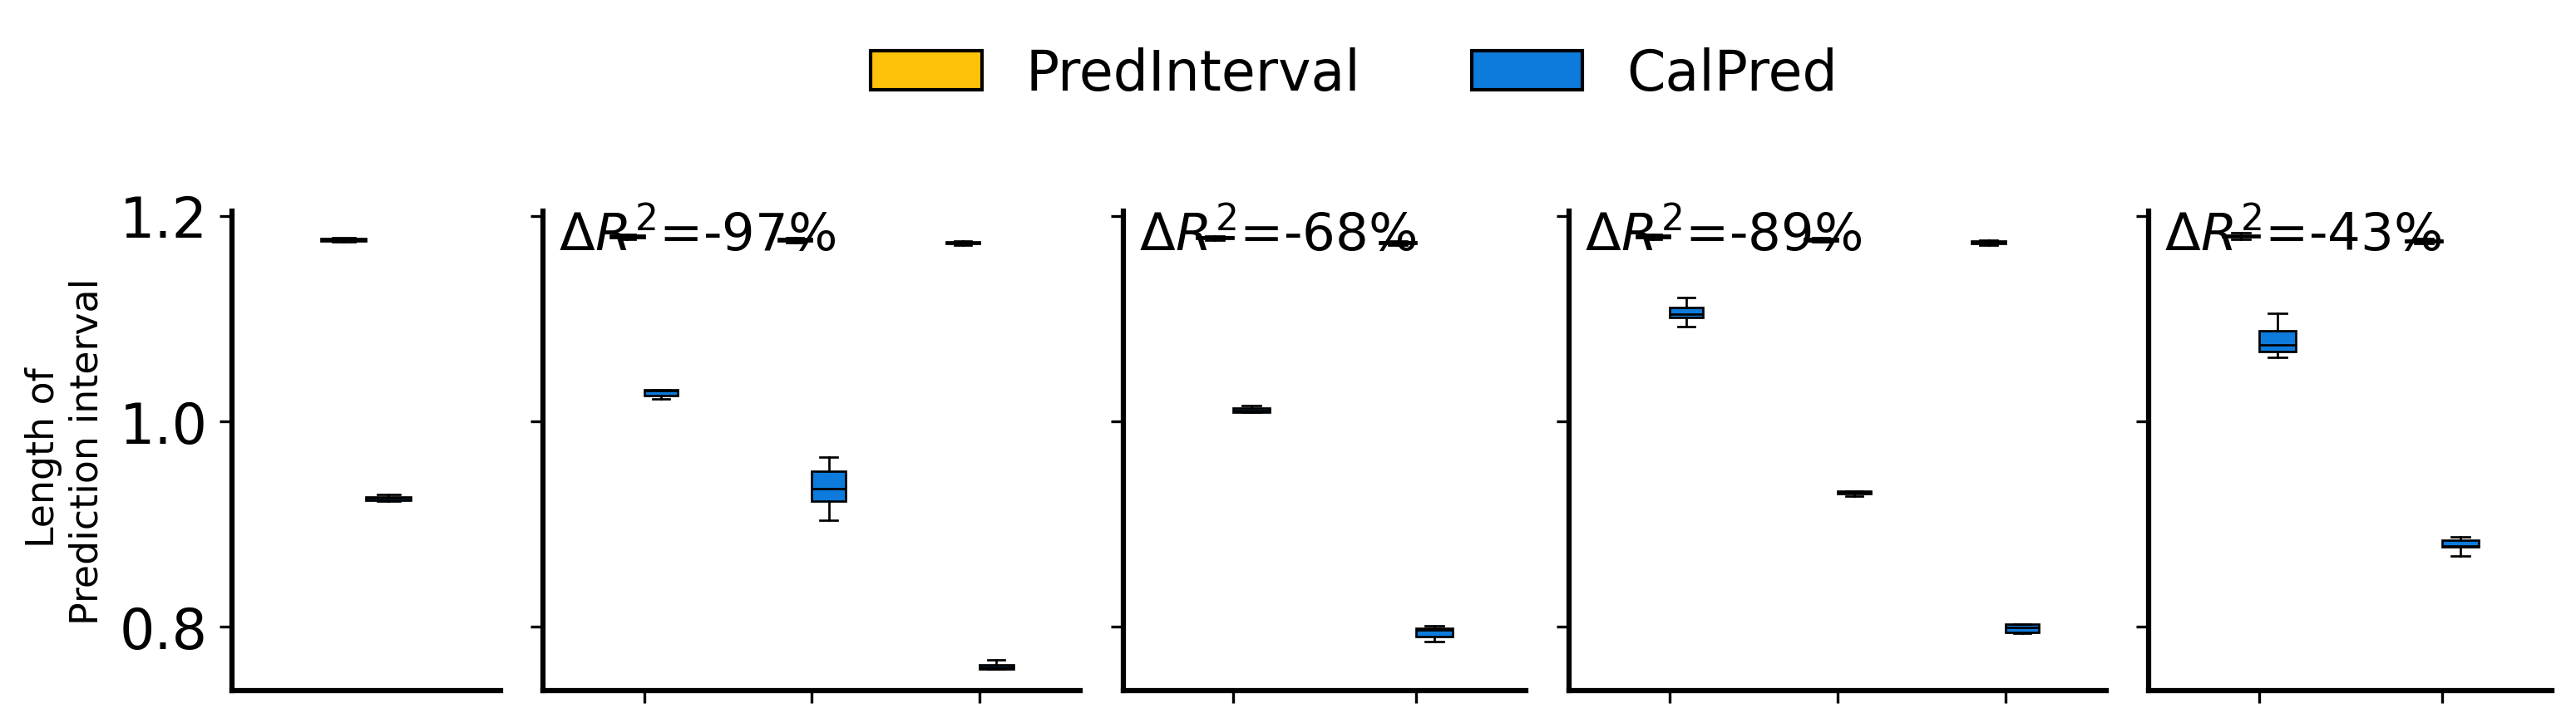

In [5]:
def fix_xaxis(axes,none=False,r2=None):
    axes[0].set_xticks([])
    if none:
        for i in range(0,5):
            axes[i].set_xticklabels([])
            axes[i].set_xlabel("")
    else:

        axes[1].set_xlabel("Age Strata")
        axes[1].set_xticklabels(["Top","Middle","Bottom"],fontsize=12)

        axes[2].set_xlabel("Sex")
        axes[2].set_xticklabels(["Female", "Male"],fontsize=15)
        axes[3].set_xlabel("Income Strata")
        axes[3].set_xticklabels(["Top","Middle","Bottom"],fontsize=12)

        axes[4].set_xlabel("Education Strata")
        axes[4].set_xticklabels(["Top","Bottom"],fontsize=15)
        
    for ax in axes:
        ax.spines[['right', 'top']].set_visible(False)
        
    contexts = [("age",0,9),("sex",0,1),("income",1,9),("education",1,4)]
    
    deltas=[]
    
    for context in contexts:
        values = []
        for seed in range(10):
            for cv in range(1,6):
                values.append((r2[(r2.col==f"{context[0]}_q_{context[2]}") & (r2.seed == seed) & (r2.cv==cv)].r2.values[0]-r2[(r2.col==f"{context[0]}_q_{context[1]}") & (r2.seed == seed) & (r2.cv==cv)].r2.values[0])/r2[(r2.col==f"marginal") & (r2.seed == seed) & (r2.cv==cv)].r2.values[0])
        deltas.append(np.mean(values))


    for i in range(4):
        deltar2 = deltas[i]
        axes[i+1].set_title(f" $\\Delta R^2$={deltar2:.0%}",fontsize=15,loc="left",y=0.875)



r2 = pd.read_csv("data/f3_BMI_r2.tsv",sep="\t").fillna("")
df_tmp = pd.read_csv("data/f3_BMI_result.tsv",sep="\t").fillna("")   
    
    

# plot
fig_r2, axes_r2 = calpgs.plot_group_r2(
    df=r2,
    groups=["Overall", "Age","Sex","Income", "Education"],
    figsize=(12, 2.5)
)
axes_r2[2].set_title("BMI")

fig_coverage, axes_coverage, fig_length, axes_length = calpgs.plot_group_predint(
    df=df_tmp,
    pos_offset=0.2,
    figsize=(12,2.5),
    groups=["Overall", "Age","Sex","Income", "Education"],
    methods=["PredInterval","CalPred"],
    method_colors={"CalPred": "#0C7BDC", "PredInterval":"#FFC20A"},
    legend_bbox_to_anchor=(0.5, 1.1),
    legend_fontsize=16,
)
axes_coverage[2].set_title("BMI")
axes_coverage[0].set_ylabel("Coverage\nat 95% percentile", fontsize=16)
axes_r2[0].set_ylabel("$R^2 (pgs, y_{resid})$", fontsize=16)

for ax in axes_coverage:
    ax.set_ylim(0.89, 1.01)
    ax.axhline(y=0.95, color="red", lw=0.8, ls="--") 
    
for axes in [axes_r2, axes_coverage, axes_length]:
    fix_xaxis(axes,1,r2)


fig_coverage.savefig("figures/fig3_bmi_gwas_alpha95.PGS_resid.png",bbox_inches='tight')
fig_r2.savefig("figures/fig3_bmi_gwas_alpha95.r2.PGS_resid.png",bbox_inches='tight')


# Replication of LDL using UKB PGS

Overall
Age
Sex
Income
Education


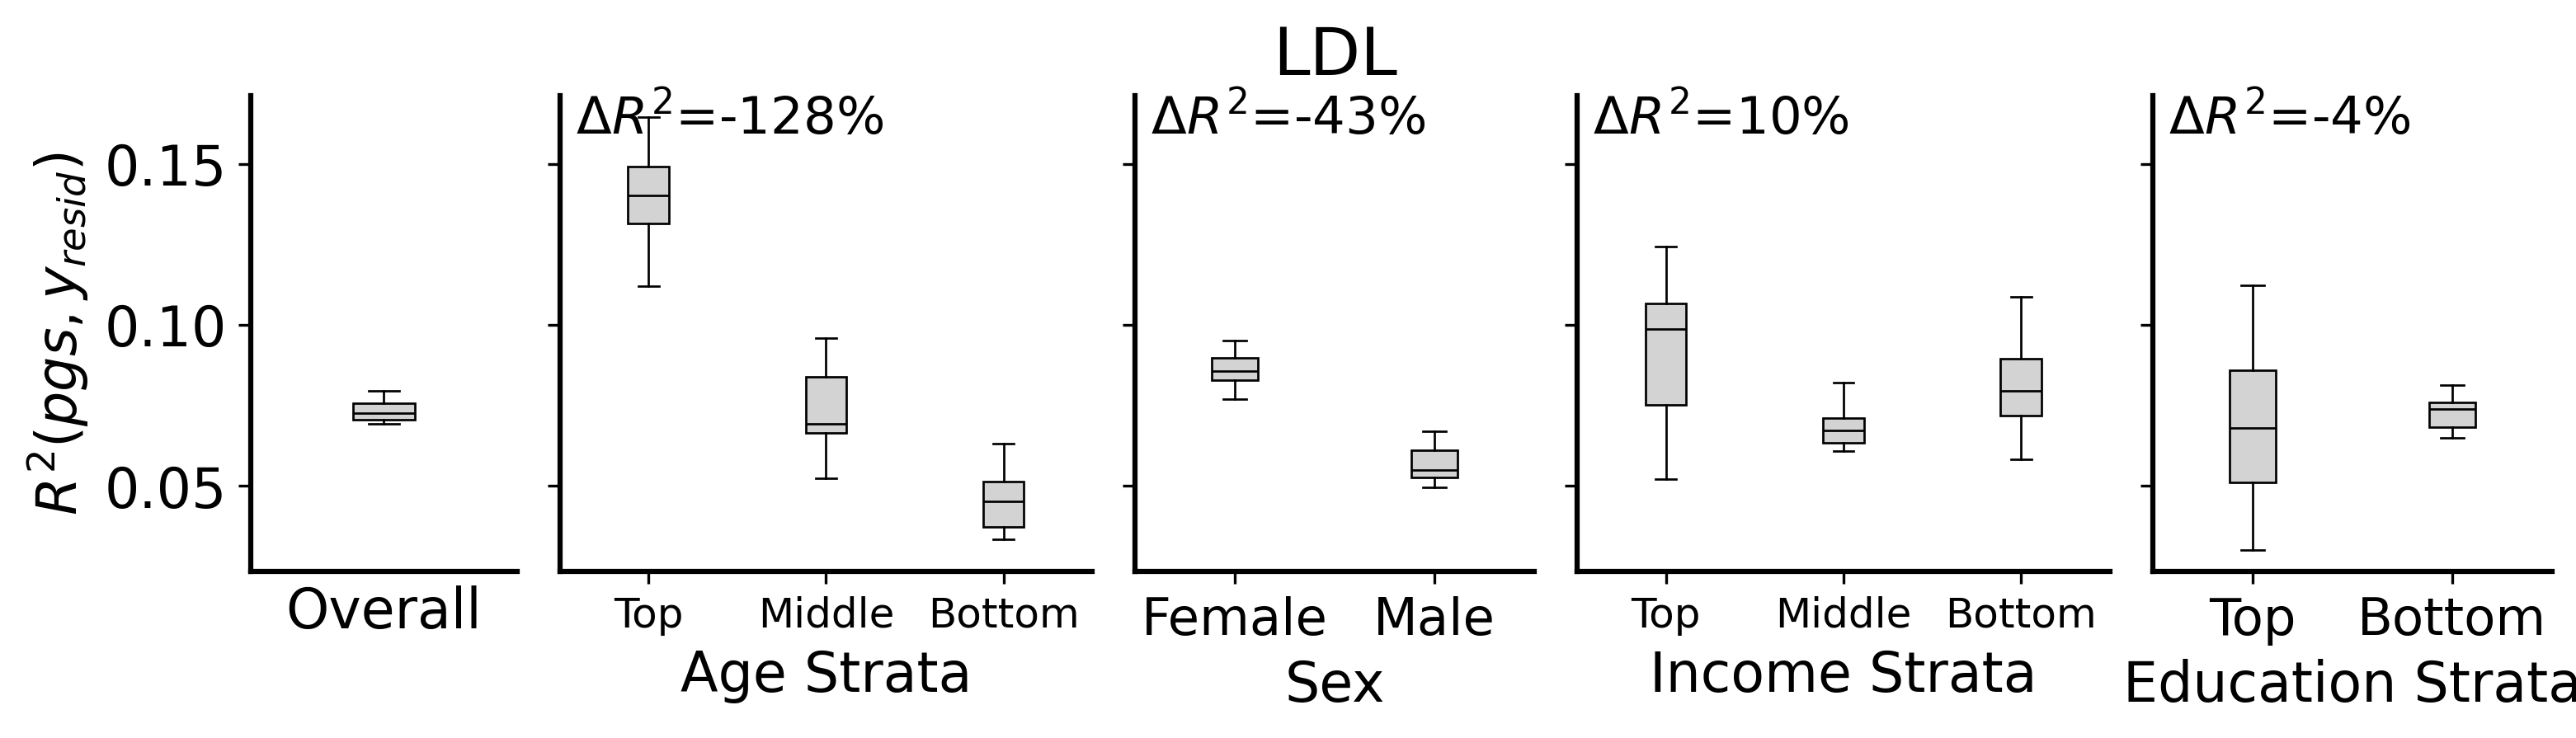

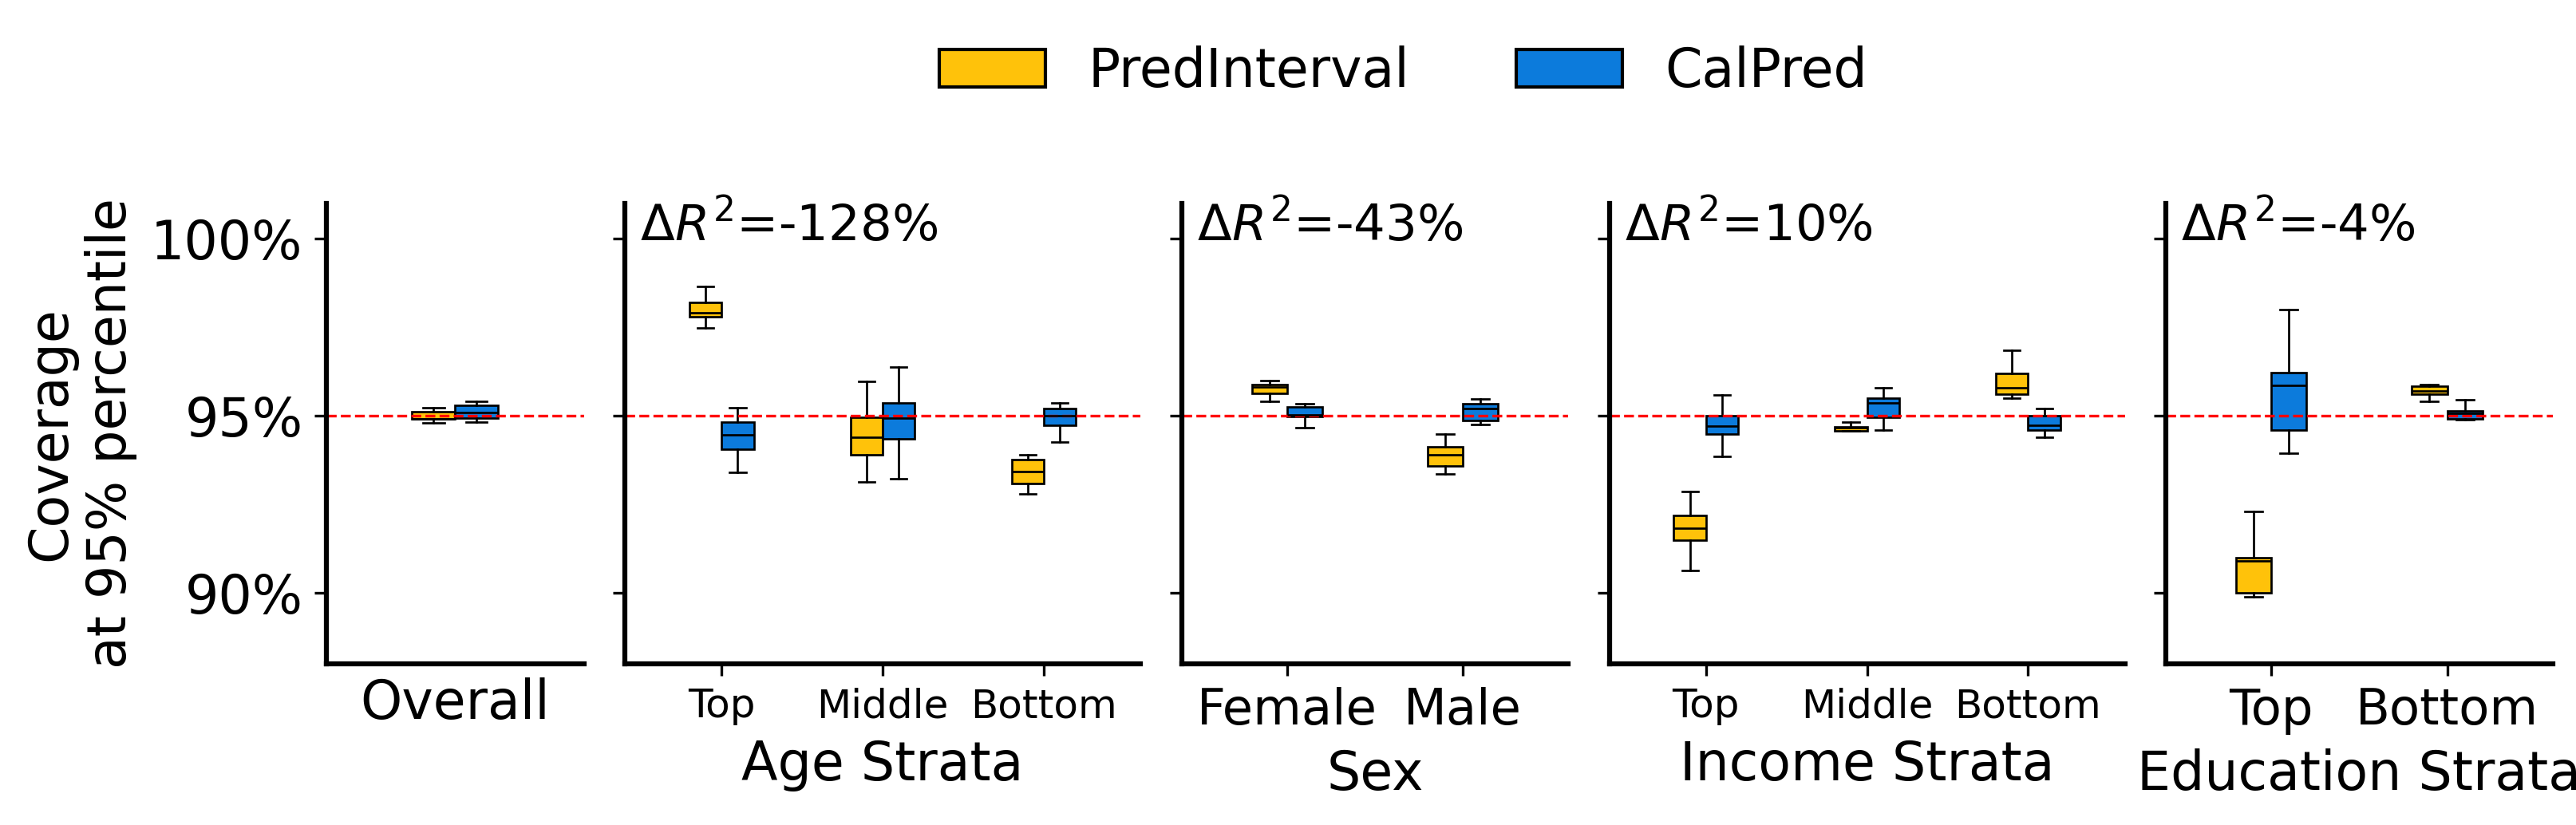

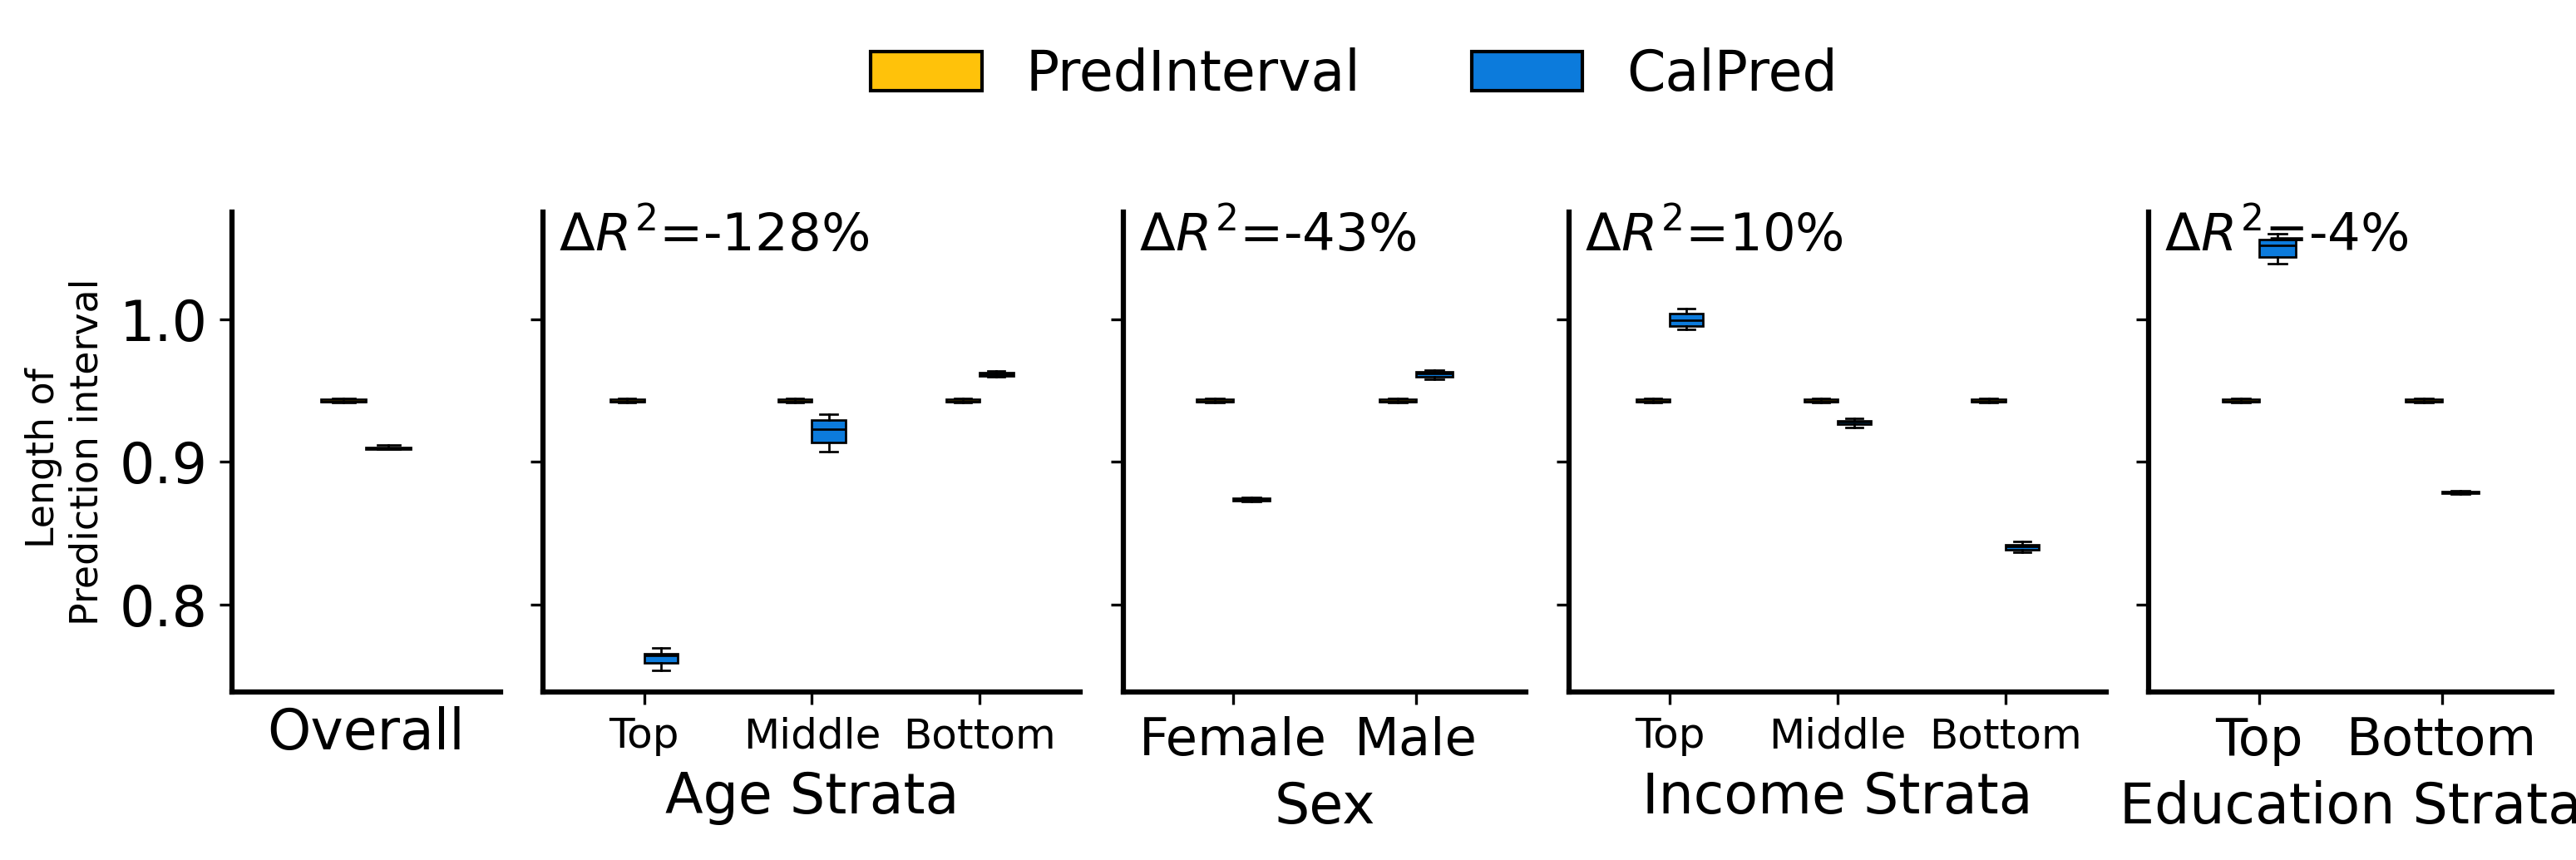

In [6]:
def fix_xaxis(axes,none=False,r2=None):
    axes[0].set_xticks([])
    if none:
        for i in range(0,5):
            axes[i].set_xticklabels([])
            axes[i].set_xlabel("")
    else:

        axes[1].set_xlabel("Age Strata")
        axes[1].set_xticklabels(["Top","Middle","Bottom"],fontsize=12)

        axes[2].set_xlabel("Sex")
        axes[2].set_xticklabels(["Female", "Male"],fontsize=15)
        axes[3].set_xlabel("Income Strata")
        axes[3].set_xticklabels(["Top","Middle","Bottom"],fontsize=12)
        # age quintile
        axes[4].set_xlabel("Education Strata")
        axes[4].set_xticklabels(["Top","Bottom"],fontsize=15)
        
    for ax in axes:
        ax.spines[['right', 'top']].set_visible(False)
    
    contexts = [("age",0,9),("sex",0,1),("income",1,9),("education",1,4)]
    
    
    overall = r2[r2.col=="all"].r2.values[0]
    for i in range(4):
        c = contexts[i][0]

        top = r2[r2.col==f"{c}_{contexts[i][2]}"].r2.values[0]
        bot = r2[r2.col==f"{c}_{contexts[i][1]}"].r2.values[0]

        deltar2 = (top-bot)/overall
        axes[i+1].set_title(f" $\\Delta R^2$={deltar2:.0%}",fontsize=15,loc="left",y=0.875)
        

    

r2 = pd.read_csv("data/f3_LDL_r2_ukb.tsv",sep="\t").fillna("")
df_tmp = pd.read_csv("data/f3_LDL_result_ukb.tsv",sep="\t").fillna("")   


# plot
fig_r2, axes_r2 = calpgs.plot_group_r2(
    df=r2,
    groups=["Overall", "Age","Sex","Income", "Education"],
    figsize=(12,2.5),
)
axes_r2[2].set_title("LDL")


fig_coverage, axes_coverage, fig_length, axes_length = calpgs.plot_group_predint(
    df=df_tmp,
    pos_offset=0.2,
    figsize=(12,2.5),
    groups=["Overall", "Age","Sex","Income", "Education"],
    methods=["PredInterval","CalPred"],
    method_colors={"CalPred": "#0C7BDC", "PredInterval":"#FFC20A"},
    legend_bbox_to_anchor=(0.5, 1.1),
    legend_fontsize=16
)


axes_coverage[0].set_ylabel("Coverage\nat 95% percentile", fontsize=16)
axes_r2[0].set_ylabel("$R^2 (pgs, y_{resid})$", fontsize=16)
for ax in axes_coverage:
    ax.set_ylim(0.88, 1.01)
    ax.axhline(y=0.95, color="red", lw=0.8, ls="--")

    
    
    
for axes in [axes_r2, axes_coverage, axes_length]:
    fix_xaxis(axes,0,r2)


fig_coverage.savefig("figures/fig3_ldl_external_alpha95.PGS_resid.png",bbox_inches='tight')
fig_r2.savefig("figures/fig3_ldl_external_alpha95.r2.PGS_resid.png",bbox_inches='tight')


# Replication of BMI using UKB PGS

Overall
Age
Sex
Income
Education


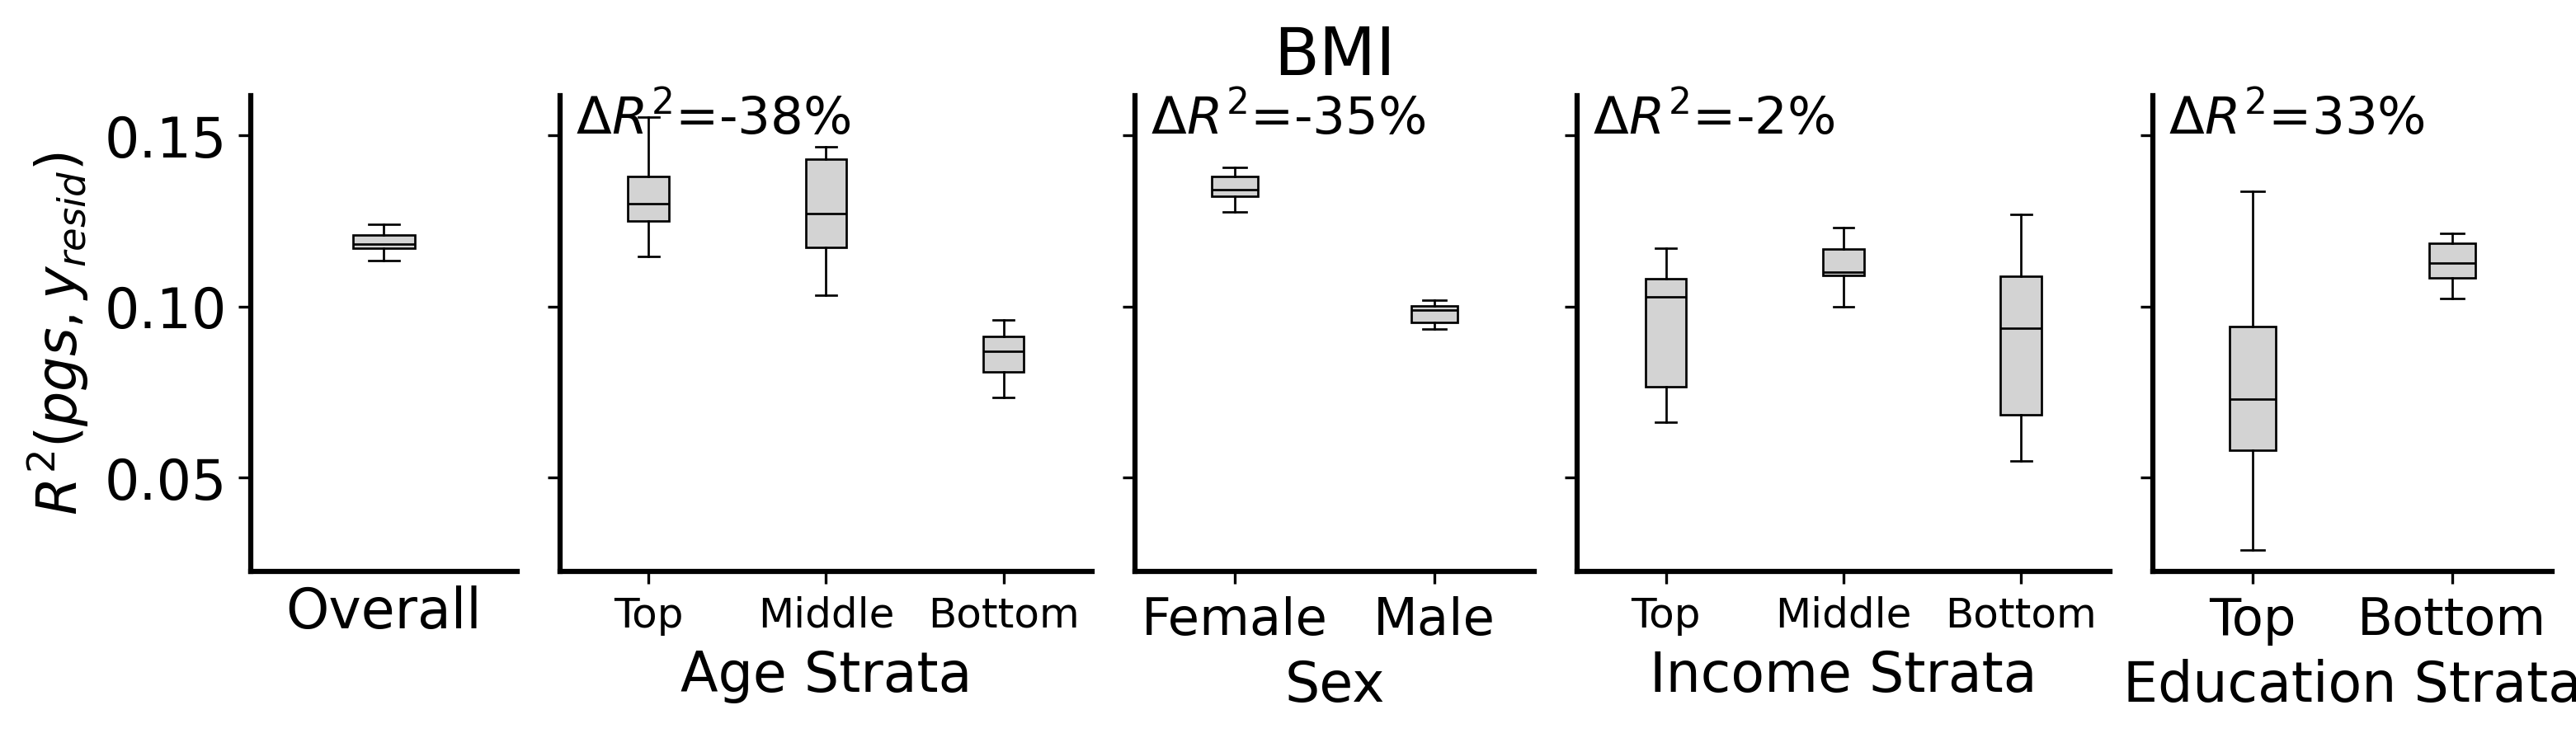

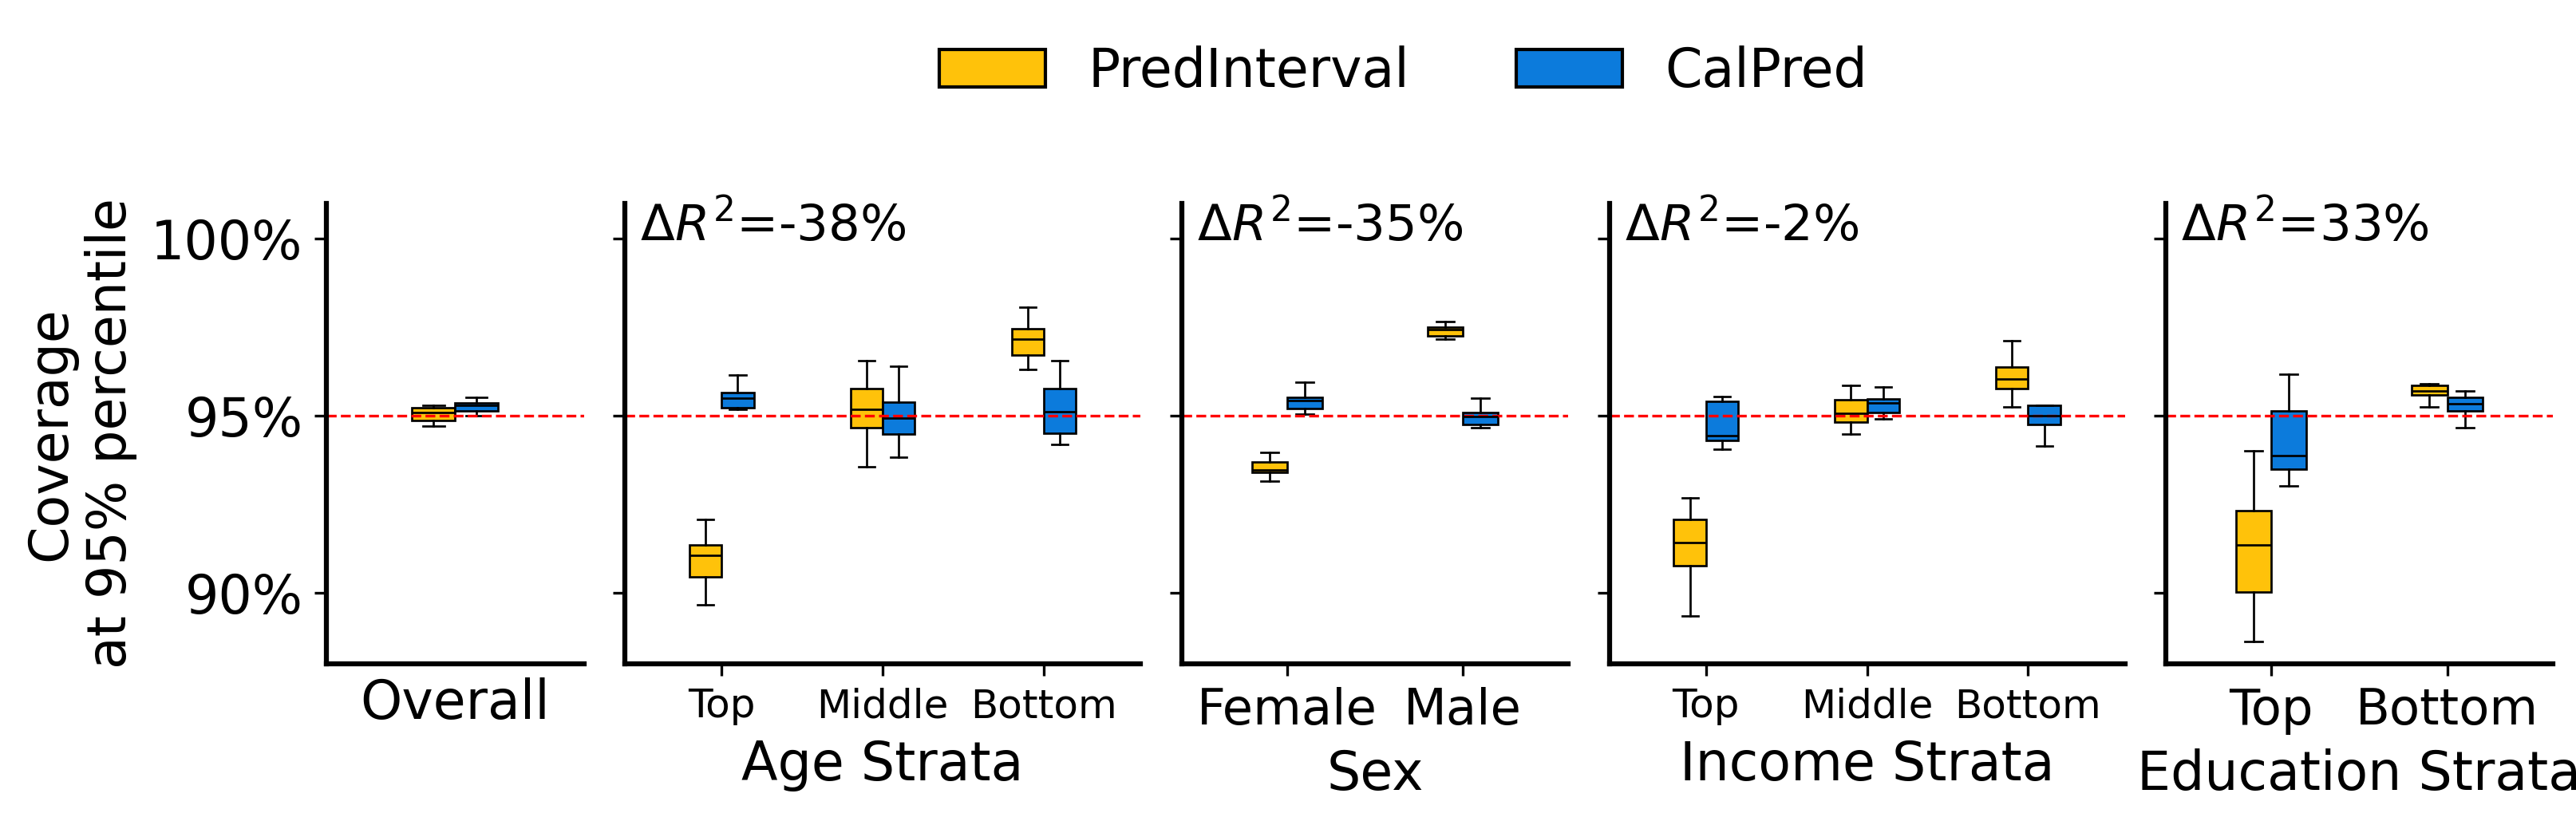

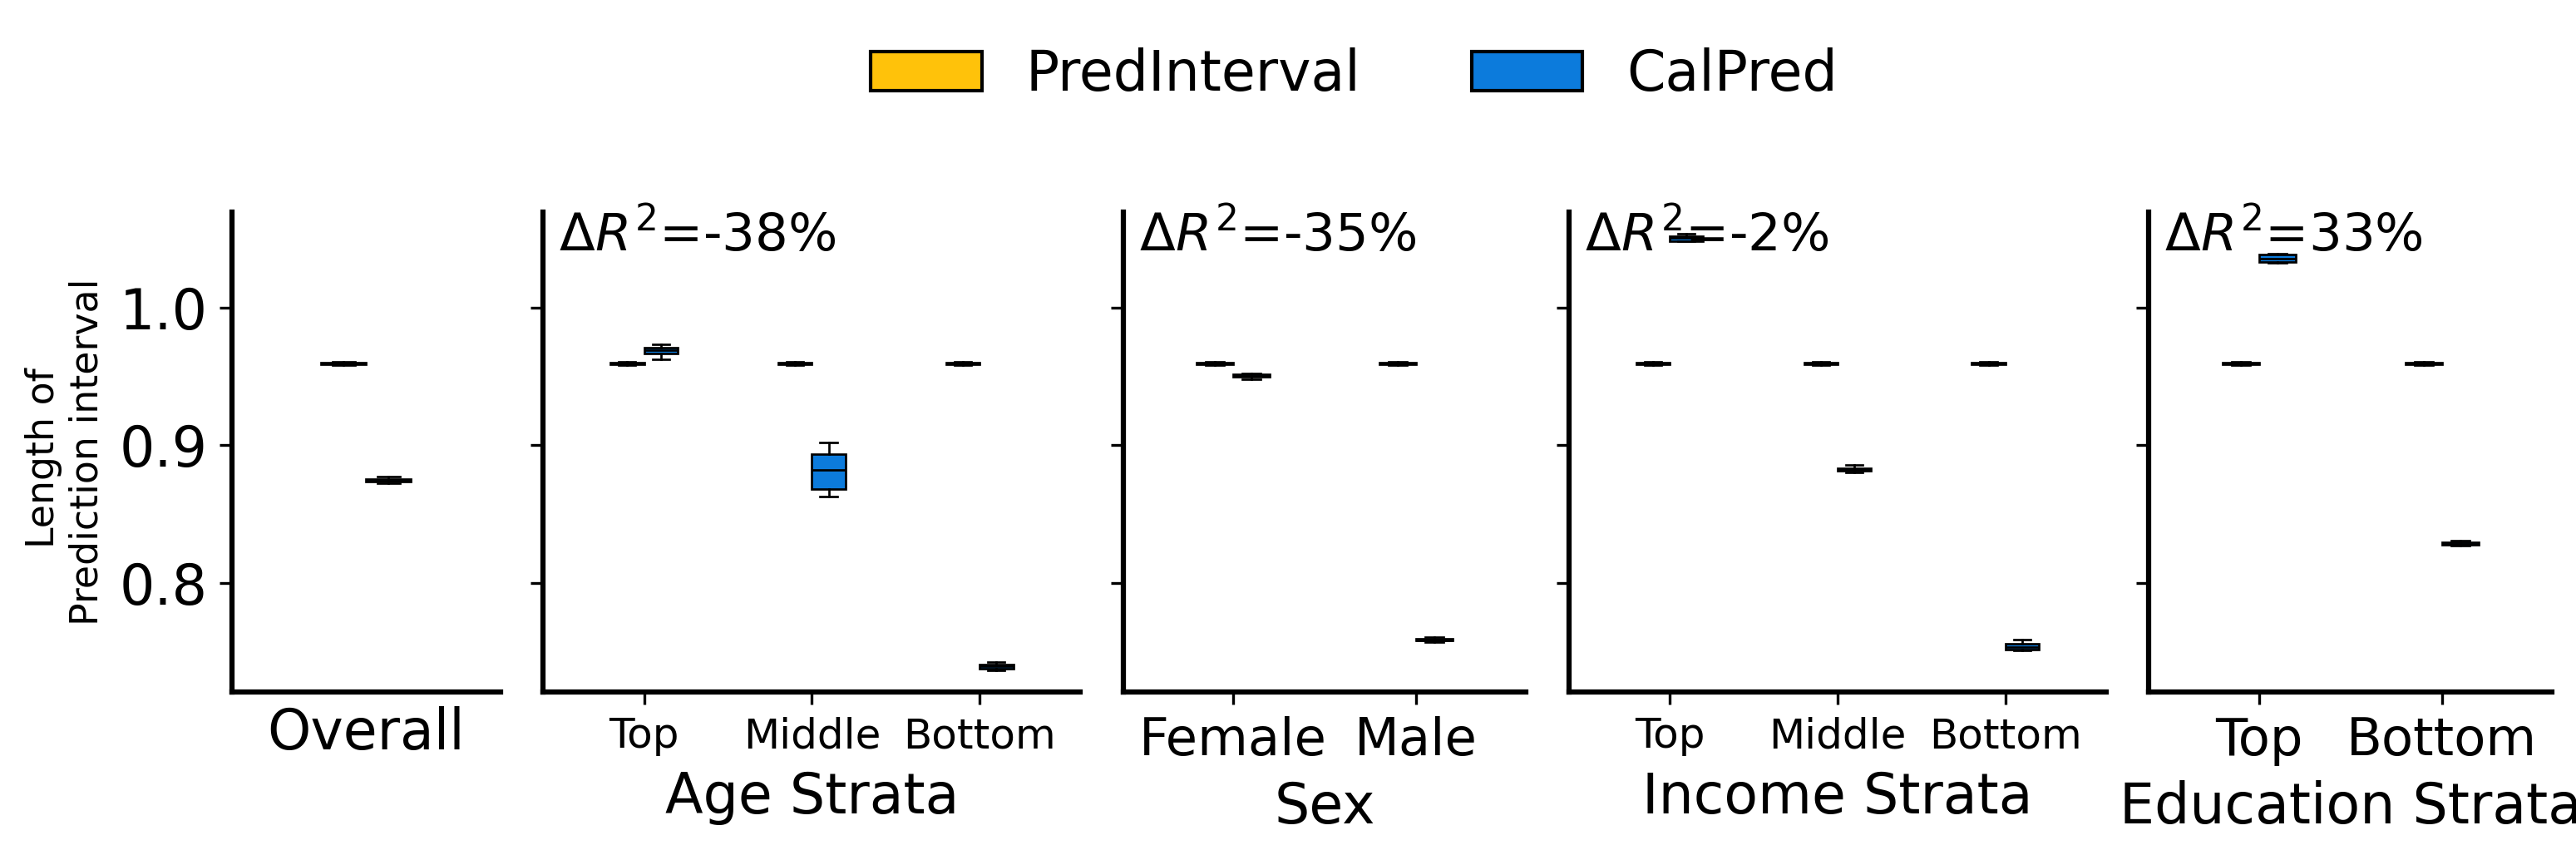

In [7]:
def fix_xaxis(axes,none=False,r2=None):
    axes[0].set_xticks([])
    if none:
        for i in range(0,5):
            axes[i].set_xticklabels([])
            axes[i].set_xlabel("")
    else:

        axes[1].set_xlabel("Age Strata")
        axes[1].set_xticklabels(["Top","Middle","Bottom"],fontsize=12)

        axes[2].set_xlabel("Sex")
        axes[2].set_xticklabels(["Female", "Male"],fontsize=15)
        axes[3].set_xlabel("Income Strata")
        axes[3].set_xticklabels(["Top","Middle","Bottom"],fontsize=12)
        # age quintile
        axes[4].set_xlabel("Education Strata")
        axes[4].set_xticklabels(["Top","Bottom"],fontsize=15)
        
    for ax in axes:
        ax.spines[['right', 'top']].set_visible(False)
    
    contexts = [("age",0,9),("sex",0,1),("income",1,9),("education",1,4)]
    
    
    overall = r2[r2.col=="all"].r2.values[0]
    for i in range(4):
        c = contexts[i][0]

        top = r2[r2.col==f"{c}_{contexts[i][2]}"].r2.values[0]
        bot = r2[r2.col==f"{c}_{contexts[i][1]}"].r2.values[0]

        deltar2 = (top-bot)/overall
        axes[i+1].set_title(f" $\\Delta R^2$={deltar2:.0%}",fontsize=15,loc="left",y=0.875)
        

    

r2 = pd.read_csv("data/f3_BMI_r2_ukb.tsv",sep="\t").fillna("")
df_tmp = pd.read_csv("data/f3_BMI_result_ukb.tsv",sep="\t").fillna("")   


# plot
fig_r2, axes_r2 = calpgs.plot_group_r2(
    df=r2,
    groups=["Overall", "Age","Sex","Income", "Education"],
    figsize=(12,2.5),
)
axes_r2[2].set_title("BMI")


fig_coverage, axes_coverage, fig_length, axes_length = calpgs.plot_group_predint(
    df=df_tmp,
    pos_offset=0.2,
    figsize=(12,2.5),
    groups=["Overall", "Age","Sex","Income", "Education"],
    methods=["PredInterval","CalPred"],
    method_colors={"CalPred": "#0C7BDC", "PredInterval":"#FFC20A"},
    legend_bbox_to_anchor=(0.5, 1.1),
    legend_fontsize=16
)


axes_coverage[0].set_ylabel("Coverage\nat 95% percentile", fontsize=16)
axes_r2[0].set_ylabel("$R^2 (pgs, y_{resid})$", fontsize=16)
for ax in axes_coverage:
    ax.set_ylim(0.88, 1.01)
    ax.axhline(y=0.95, color="red", lw=0.8, ls="--")

    
    
    
for axes in [axes_r2, axes_coverage, axes_length]:
    fix_xaxis(axes,0,r2)


fig_coverage.savefig("figures/fig3_bmi_external_alpha95.PGS_resid.png",bbox_inches='tight')
fig_r2.savefig("figures/fig3_bmi_external_alpha95.r2.PGS_resid.png",bbox_inches='tight')
